Shape: (1000, 12)

Columns:
 Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'InternetService', 'MonthlyCharges',
       'Contract', 'TotalCharges', 'Churn'],
      dtype='object')

Data Types:
 customerID          object
gender              object
SeniorCitizen        int64
Partner             object
Dependents          object
tenure               int64
PhoneService        object
InternetService     object
MonthlyCharges     float64
Contract            object
TotalCharges       float64
Churn               object
dtype: object

Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
InternetService    85
MonthlyCharges      0
Contract            0
TotalCharges        0
Churn               0
dtype: int64

Statistical Summary:
        SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    1000.000000  1000.

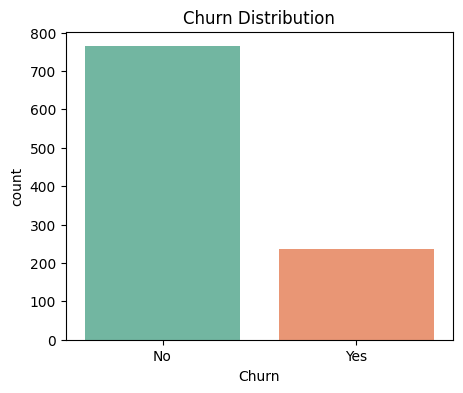

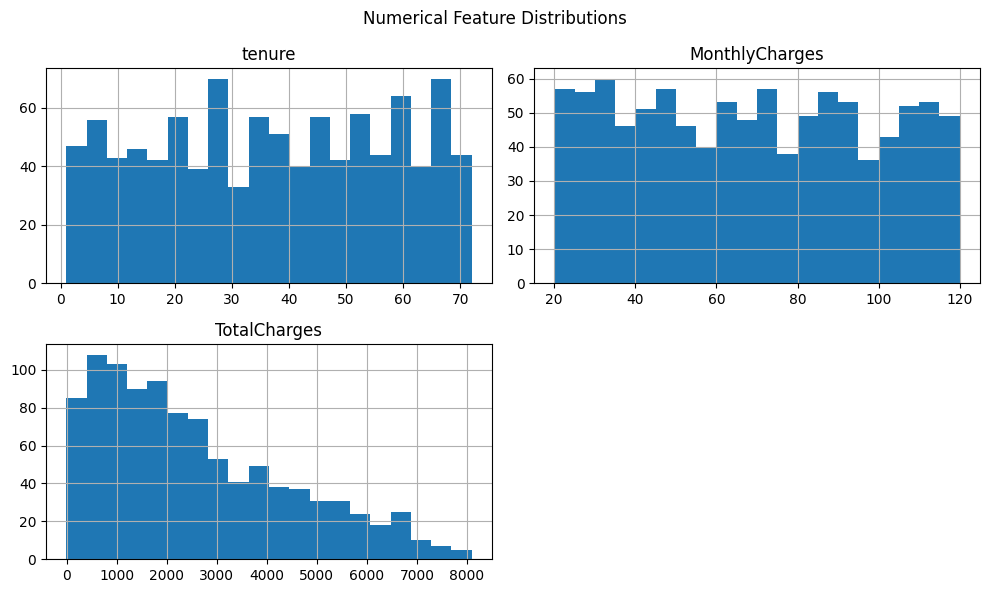

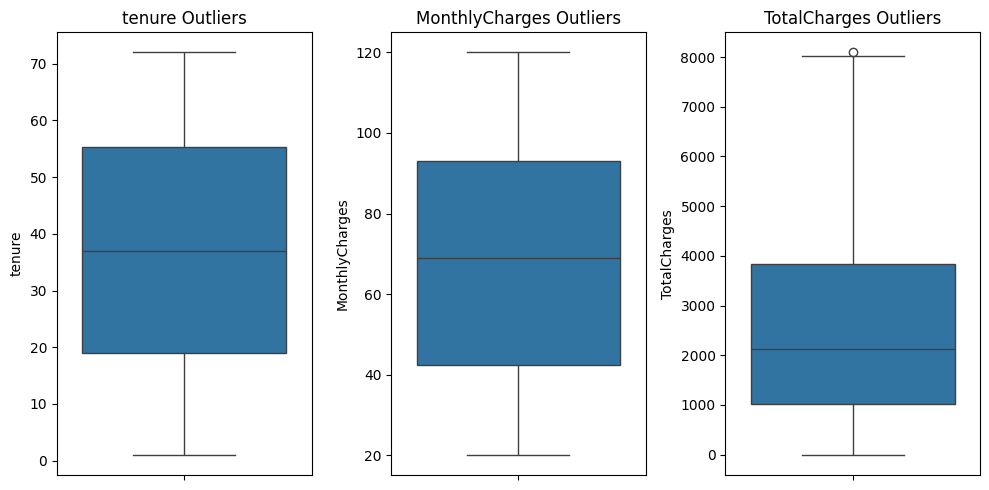

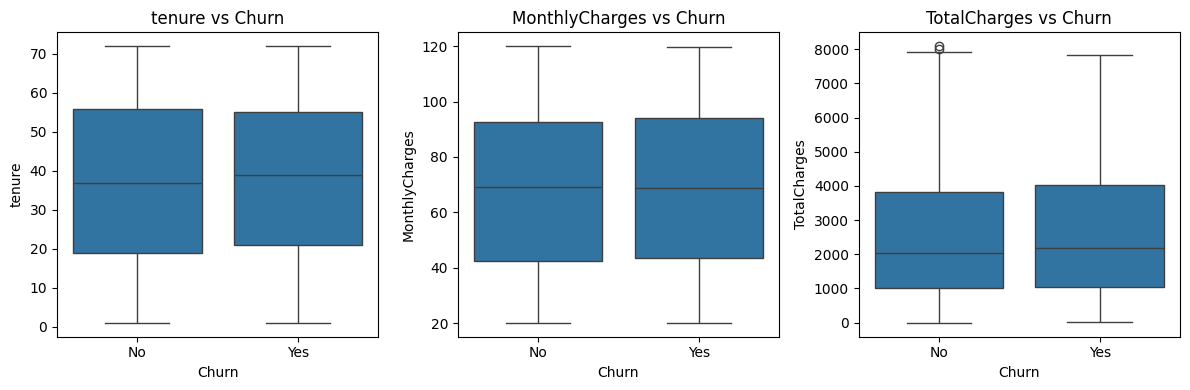

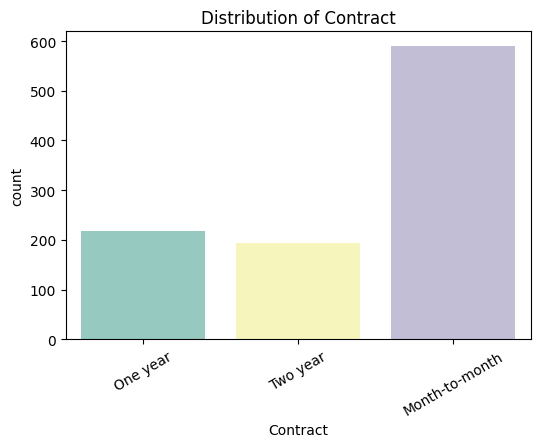

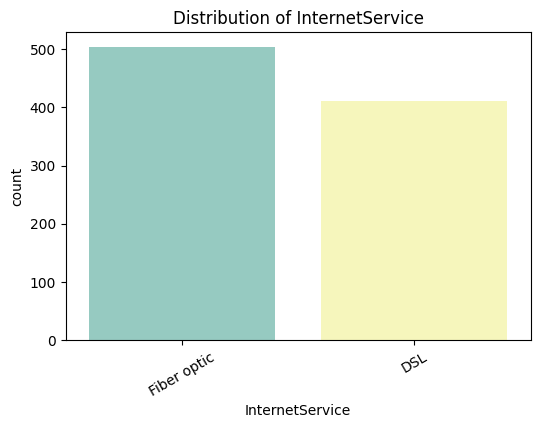

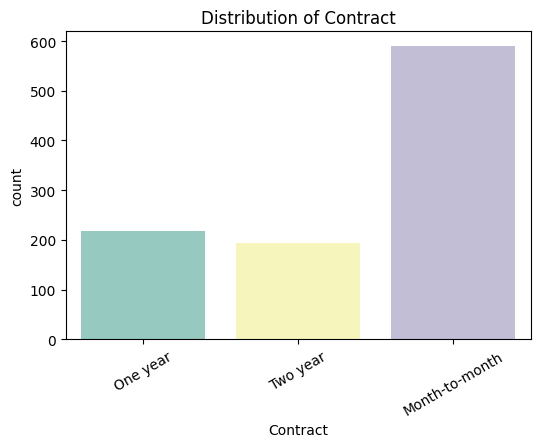

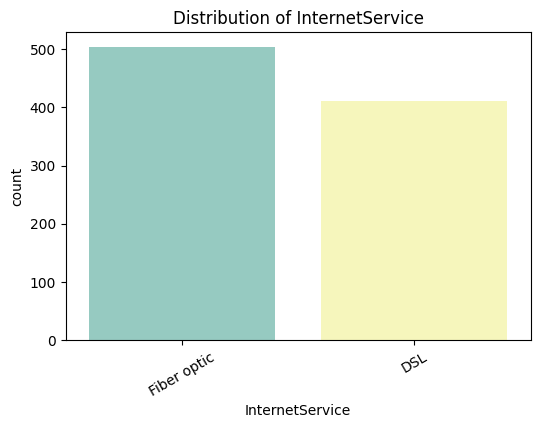

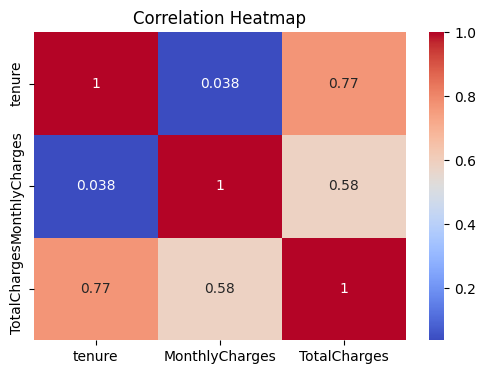

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("customer_churn_1000.csv")

# 1. BASIC INFO

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

# 2. STATISTICAL SUMMARY

print("\nStatistical Summary:\n", df.describe())

# 3. CHURN DISTRIBUTION

plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Churn", hue="Churn", palette="Set2", legend=False)
plt.title("Churn Distribution")
plt.show()

# 4. NUMERICAL DISTRIBUTIONS

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

df[num_cols].hist(figsize=(10,6), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.tight_layout()
plt.show()

# 5. BOX PLOTS FOR OUTLIERS
plt.figure(figsize=(10,5))

for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f"{col} Outliers")
plt.tight_layout()
plt.show()

# 6. CHURN vs NUMERICAL FEATURES

plt.figure(figsize=(12,4))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=df, x="Churn", y=col)
    plt.title(f"{col} vs Churn")
plt.tight_layout()
plt.show()


# 7. CATEGORICAL FEATURE DISTRIBUTION


cat_cols = ["Contract", "InternetService"]

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue=col, palette="Set3", legend=False)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=30)
    plt.show()

# 8. CATEGORICAL FEATURES vs CHURN

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue=col, palette="Set3", legend=False)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=30)
    plt.show()


# 9. CORRELATION HEATMAP

plt.figure(figsize=(6,4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [8]:
from sklearn.preprocessing import LabelEncoder

df = df.copy()

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include="object"):
    df[col] = le.fit_transform(df[col])

print(df.head())


   customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0           0       1              0        0           0      51   
1           1       0              0        0           1      47   
2           2       1              0        0           1       4   
3           3       1              0        0           1       7   
4           4       1              0        1           0      35   

   PhoneService  InternetService  MonthlyCharges  Contract  TotalCharges  \
0             1                1           43.60         1       2251.39   
1             1                1           34.35         1       1648.58   
2             1                2           38.54         2        162.14   
3             1                0           38.21         1        279.36   
4             1                0           71.29         0       2473.44   

   Churn  
0      0  
1      1  
2      0  
3      0  
4      0  


In [9]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [14]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

models = [("Logistic Regression", lr),
          ("Random Forest", rf)]

for name, model in models:
    preds = model.predict(X_test)
    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
    print("Classification Report:\n", classification_report(y_test, preds))



 Logistic Regression
Accuracy: 0.75
Confusion Matrix:
 [[150   0]
 [ 50   0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      1.00      0.86       150
           1       0.00      0.00      0.00        50

    accuracy                           0.75       200
   macro avg       0.38      0.50      0.43       200
weighted avg       0.56      0.75      0.64       200


 Random Forest
Accuracy: 0.745
Confusion Matrix:
 [[145   5]
 [ 46   4]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.97      0.85       150
           1       0.44      0.08      0.14        50

    accuracy                           0.74       200
   macro avg       0.60      0.52      0.49       200
weighted avg       0.68      0.74      0.67       200



C:\Users\likithkumar\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\likithkumar\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\likithkumar\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,